# Section B: Practical Task

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### 1. Automated Data Ingestion Pipeline & Type-Casting

In [12]:
df = pd.read_csv('heart.csv')

In [13]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [14]:
categorical_cols = ['sex', 'cp', 'restecg']

In [15]:
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [16]:
df.dtypes

id             int64
age            int64
sex         category
dataset          str
cp          category
trestbps     float64
chol         float64
fbs           object
restecg     category
thalch       float64
exang         object
oldpeak      float64
slope            str
ca           float64
thal             str
num            int64
dtype: object

### 2. Comprehensive Outlier Detection (IQR Method) & Visualization

In [17]:
Q1_chol = df['chol'].quantile(0.25)
Q3_chol = df['chol'].quantile(0.75)
IQR_chol = Q3_chol - Q1_chol

In [18]:
chol_outliers = df[(df['chol'] < (Q1_chol - 1.5 * IQR_chol)) | (df['chol'] > (Q3_chol + 1.5 * IQR_chol))]
len(chol_outliers)

183

In [21]:
Q1_thal = df['thalch'].quantile(0.25)
Q3_thal = df['thalch'].quantile(0.75)
IQR_thal = Q3_thal - Q1_thal

In [23]:
thalach_outliers = df[(df['thalch'] < (Q1_thal - 1.5 * IQR_thal)) | (df['thalch'] > (Q3_thal + 1.5 * IQR_thal))]
len(thalach_outliers)

2

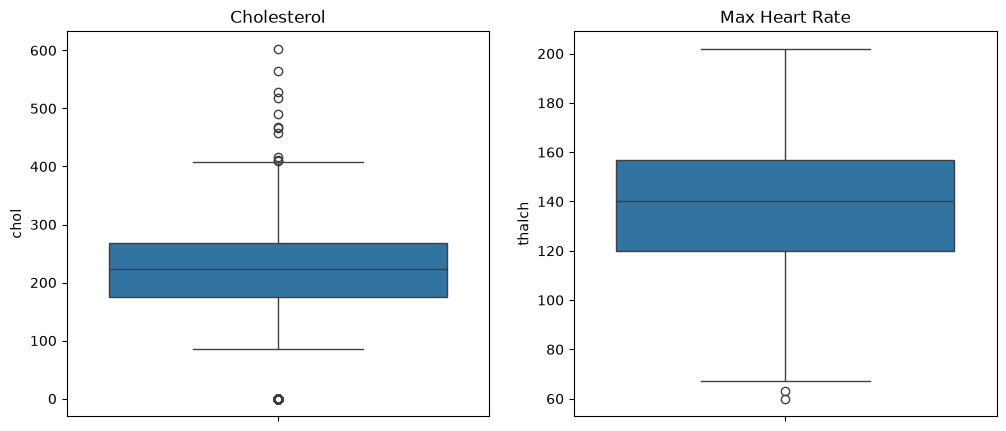

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['chol'], ax=axes[0])
axes[0].set_title('Cholesterol')
sns.boxplot(y=df['thalch'], ax=axes[1])
axes[1].set_title('Max Heart Rate')
plt.show()

### 3. Multivariate Analysis: Heatmaps & Correlation

In [27]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

In [28]:
corr_matrix = df[numeric_cols].corr()

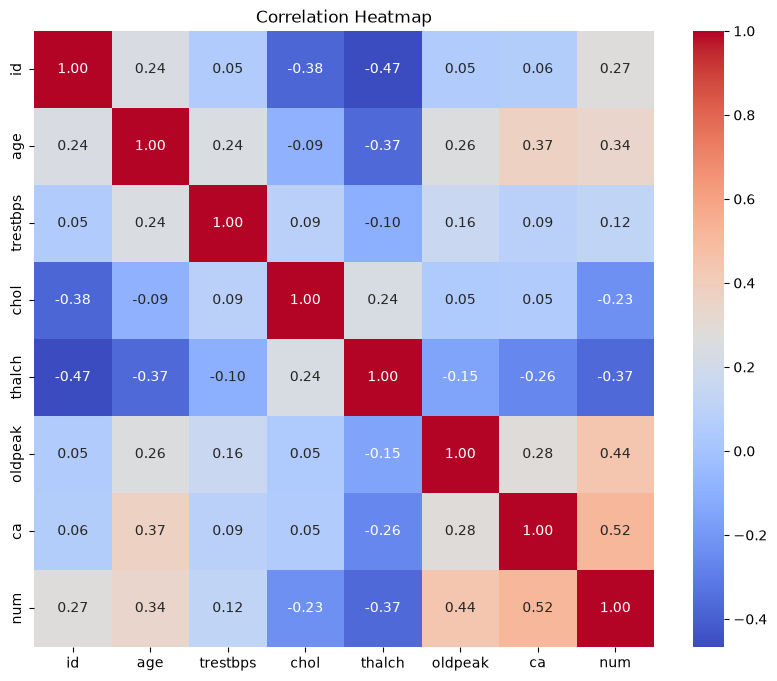

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
target_corr = corr_matrix['num'].drop('num').sort_values(ascending=False)
target_corr

ca          0.516216
oldpeak     0.443084
age         0.339596
id          0.273552
trestbps    0.122291
chol       -0.231547
thalch     -0.366265
Name: num, dtype: float64

### 4. Feature Engineering: Normalization & Derived Features

In [33]:
df['theoretical_max_hr'] = 220 - df['age']

In [35]:
df['age_adjusted_thalach_ratio'] = df['thalch'] / df['theoretical_max_hr']

In [36]:
numerical_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_adjusted_thalach_ratio']

In [37]:
scaler = StandardScaler()

In [38]:
cols_to_scale = [c for c in numerical_to_scale if c in df.columns]
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [39]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,theoretical_max_hr,age_adjusted_thalach_ratio
0,1,1.007386,Male,Cleveland,typical angina,0.675287,0.305908,True,lv hypertrophy,150.0,False,1.303159,downsloping,0.0,fixed defect,0,157,0.904054
1,2,1.432034,Male,Cleveland,asymptomatic,1.462483,0.784599,False,lv hypertrophy,108.0,True,0.569611,flat,3.0,normal,2,153,-0.809447
2,3,1.432034,Male,Cleveland,asymptomatic,-0.636705,0.269780,False,lv hypertrophy,129.0,True,1.578239,flat,2.0,reversable defect,1,153,0.133064
3,4,-1.752828,Male,Cleveland,non-anginal,-0.111908,0.459450,False,normal,187.0,False,2.403480,downsloping,0.0,normal,0,183,1.360316
4,5,-1.328180,Female,Cleveland,atypical angina,-0.111908,0.043982,False,lv hypertrophy,172.0,False,0.477918,upsloping,0.0,normal,0,179,0.941683


In [40]:
df.to_csv('cleaned_heart_disease.csv', index=False)